Adult Dataset - Selection of Queries
=============================

In [1]:
import itertools
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

from mechanism import Mechanism

### Load the dataset and its domain

**TODO**: please configure `DATA_PATH`.

In [2]:
# Find the best queries to ask by non-privately analyzing the provisional dataset (assumed to be public)

DATA_PATH = Path('../data')
ADULT_DATASET_PATH = DATA_PATH / Path('adult-dataset-pickle.zip')
DOMAIN_INFO_PATH = DATA_PATH / 'adult-domain.json'

mechanism = Mechanism(ADULT_DATASET_PATH, DOMAIN_INFO_PATH)

data = mechanism.load_data(ADULT_DATASET_PATH)
domain = mechanism.domain

2025-09-30 20:51:28.697 | INFO     | mechanism:__init__:61 - Set the dataset path: ../data/adult-dataset-pickle.zip
2025-09-30 20:51:28.698 | INFO     | mechanism:__init__:66 - Loaded the domain from ../data/adult-domain.json
2025-09-30 20:51:28.699 | DEBUG    | mechanism:__init__:67 - {'age': [0, 1, 2], 'workclass': ['?', 'Federal-gov', 'Local-gov', 'Never-worked', 'Private', 'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay', 'nan'], 'fnlwgt': [0, 1, 2, 3, 4, 5], 'education': ['10th', '11th', '12th', '1st-4th', '5th-6th', '7th-8th', '9th', 'Assoc-acdm', 'Assoc-voc', 'Bachelors', 'Doctorate', 'HS-grad', 'Masters', 'Preschool', 'Prof-school', 'Some-college'], 'education-num': ['1', '10', '11', '12', '13', '14', '15', '16', '2', '3', '4', '5', '6', '7', '8', '9'], 'marital-status': ['Divorced', 'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent', 'Never-married', 'Separated', 'Widowed'], 'occupation': ['?', 'Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec

In [3]:
data.df.sample(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
6683,0,4.0,2,0,NaN,2,3.0,0,4,1,0,0,1,39.0,0
16858,0,2.0,0,15,NaN,4,1.0,4,2,0,0,0,1,39.0,0
4770,0,4.0,1,1,NaN,4,8.0,3,4,0,0,0,0,39.0,0
36432,0,4.0,3,15,NaN,4,12.0,3,4,0,0,0,0,39.0,1
16069,1,4.0,1,11,NaN,2,4.0,0,4,1,0,0,1,26.0,0
36377,1,NaN,1,11,NaN,2,NaN,0,4,1,0,0,2,39.0,1
34786,1,4.0,3,15,NaN,2,3.0,0,4,1,0,0,1,39.0,3
30549,1,2.0,1,11,NaN,0,11.0,1,4,1,0,0,1,39.0,2
30366,0,4.0,2,11,NaN,2,7.0,0,4,1,0,0,1,39.0,0
16343,1,4.0,1,8,NaN,0,10.0,1,4,1,0,0,1,39.0,0


In [4]:
domain

Domain(age: 3, workclass: 10, fnlwgt: 6, education: 16, education-num: 16, marital-status: 7, occupation: 16, relationship: 6, race: 5, sex: 2, capital-gain: 4, capital-loss: 5, hours-per-week: 4, native-country: 43, income: 4)

### Compute the mutual information

In [5]:
# Calculate the mutual information between every pair of attributes
nb_rows = len(data.df)
mutinf_pairs_df = pd.DataFrame(columns=['attr_1', 'attr_2', 'score'])
index = 0

for attr_1, attr_2 in itertools.combinations(data.domain.attrs, 2):
    # Get the relative frequency of each value of the two attributes
    A = data.project(attr_1).datavector() / nb_rows
    B = data.project(attr_2).datavector() / nb_rows
    AB = data.project([attr_1, attr_2]).datavector() / nb_rows

    # print(f'shape(A)={A.shape}, shape(B)={B.shape}, shape(AB)={AB.shape}')

    # Compute the mutual information of the two attributes
    # P(A, B) * log( P(A, B) / P(A) * P(B) )
    try:
        score = np.dot(
            AB[AB > 0],
            np.log(AB / np.outer(A, B).flatten())[AB > 0]
        )
    except RuntimeWarning:
        score = 0

    # Save the mutual inf. of A, B and B, A at the right index
    mutinf_pairs_df.loc[index] = [attr_1, attr_2, score]
    mutinf_pairs_df.loc[index + 1] = [attr_2, attr_1, score]
    index += 2

# Sort the pairs of attributes by their mutual information
mutinf_pairs_df.sort_values('score', inplace=True)

/tmp/ipykernel_489839/3924216292.py:19: RuntimeWarning: invalid value encountered in divide
  np.log(AB / np.outer(A, B).flatten())[AB > 0]
/tmp/ipykernel_489839/3924216292.py:19: RuntimeWarning: divide by zero encountered in log
  np.log(AB / np.outer(A, B).flatten())[AB > 0]
/tmp/ipykernel_489839/3924216292.py:19: RuntimeWarning: invalid value encountered in divide
  np.log(AB / np.outer(A, B).flatten())[AB > 0]
/tmp/ipykernel_489839/3924216292.py:19: RuntimeWarning: invalid value encountered in divide
  np.log(AB / np.outer(A, B).flatten())[AB > 0]
/tmp/ipykernel_489839/3924216292.py:19: RuntimeWarning: divide by zero encountered in log
  np.log(AB / np.outer(A, B).flatten())[AB > 0]
/tmp/ipykernel_489839/3924216292.py:19: RuntimeWarning: divide by zero encountered in log
  np.log(AB / np.outer(A, B).flatten())[AB > 0]
/tmp/ipykernel_489839/3924216292.py:19: RuntimeWarning: invalid value encountered in divide
  np.log(AB / np.outer(A, B).flatten())[AB > 0]
/tmp/ipykernel_489839/3924

In [6]:
# The 10 pairs of attributes showing the most mutual information
mutinf_pairs_df.tail(10)

,attr_1,attr_2,score
9,marital-status,age,0.174493
8,age,marital-status,0.174493
83,occupation,education,0.220926
82,education,occupation,0.220926
156,relationship,sex,0.271609
157,sex,relationship,0.271609
36,workclass,occupation,0.288475
37,occupation,workclass,0.288475
123,relationship,marital-status,0.725387
122,marital-status,relationship,0.725387


In [7]:
# NOTE In the original notebook, the pairs containing the three following attributes got a score increased by 100.
# SEX, CITY, INCWAGE
# IDEA They may come from the 1-marginal that are selected from a previous undocumented step?

# Create the graph with the attributes as nodes
graph = nx.Graph()
graph.add_nodes_from(domain.attrs)

# Add an edge between the pairs of attributes weighted by their mutual information (score)
for attr_1, attr_2, score in mutinf_pairs_df.itertuples(index=False):
    graph.add_edge(attr_1, attr_2, weight=score)

# Compute the maximum spanning tree (i.e., the spanning tree which total weight is maximum)
mst = nx.maximum_spanning_tree(graph)
list(mst.edges)

[('age', 'marital-status'),
 ('age', 'education-num'),
 ('workclass', 'occupation'),
 ('fnlwgt', 'native-country'),
 ('education', 'occupation'),
 ('education', 'native-country'),
 ('marital-status', 'relationship'),
 ('occupation', 'sex'),
 ('occupation', 'hours-per-week'),
 ('relationship', 'sex'),
 ('relationship', 'income'),
 ('race', 'native-country'),
 ('capital-gain', 'income'),
 ('capital-loss', 'income')]

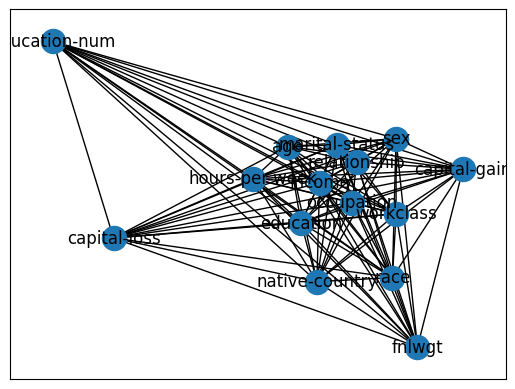

In [8]:
nx.draw_networkx(graph)

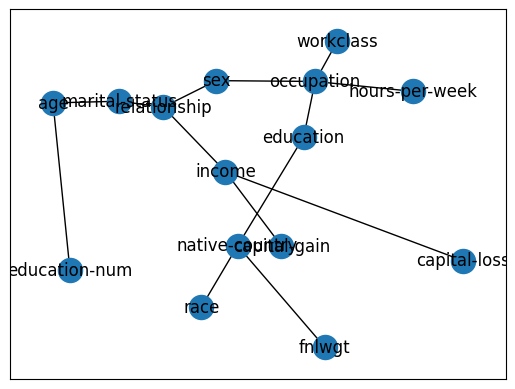

In [9]:
nx.draw_networkx(mst)

In [10]:
mutinf_triplets_df = pd.DataFrame(columns=['A', 'B', 'C', 'size', 'score'])
index = 0

for A in mst.nodes:
    for B, C in itertools.combinations(mst.neighbors(A), 2):
        # We obtain A, B, C the triplets of connected nodes in the MST
        # print(A, B, C)
        
        # AB and AC contain the relative frequency of co-occurences of the two attributes
        # print(data.df.groupby([A, B]).size().unstack().fillna(0))
        # print(data.df.groupby([A, B]).size().unstack().fillna(0) / nb_rows)
        AB = data.df.groupby([A, B]).size().unstack().fillna(0).values / nb_rows
        AC = data.df.groupby([A, C]).size().unstack().fillna(0).values / nb_rows
        
        # We get the size of the matrices
        size_a, size_b = AB.shape
        size_a, size_c = AC.shape
        
        # Set AB and AC to three dimensions by adding one dimension of size 1
        try:
            AB = AB.reshape(size_a, size_b, 1)
            AC = AC.reshape(size_a, 1, size_c)
        except ValueError:
            continue

        ABC2 = AB * AC / AB.sum(axis=1, keepdims=True)
        
        # ABC contains the relative frequency of co-occurences of the three attributes
        # print(data.df.groupby([A, B, C]).size().unstack().fillna(0).unstack().fillna(0).stack().stack())
        ABC = (data.df.groupby([A, B, C]).size().unstack().fillna(0).unstack().fillna(0).stack().stack().values
               .reshape(size_a, size_b, size_c) / nb_rows)

        score = np.abs(ABC - ABC2).sum()
        mutinf_triplets_df.loc[index] = [A, B, C, size_a * size_b * size_c, score]
        index = index + 1

In [11]:
mutinf_triplets_df

,A,B,C,size,score
0,education,occupation,native-country,10080,0.090577
1,marital-status,relationship,age,126,0.172994
2,occupation,workclass,education,2160,0.112061
3,occupation,workclass,sex,270,0.071945
4,occupation,workclass,hours-per-week,540,0.095673
5,occupation,education,sex,480,0.087026
6,occupation,education,hours-per-week,960,0.122812
7,occupation,sex,hours-per-week,120,0.094836
8,relationship,marital-status,sex,84,0.054136
9,relationship,marital-status,income,168,0.021257


**TODO**: please configure `MINIMUM_SCORE`.

Processing of age:

Processing of workclass:

Processing of fnlwgt:

Processing of education:
education, occupation, native-country: score = 0.09057664706226494


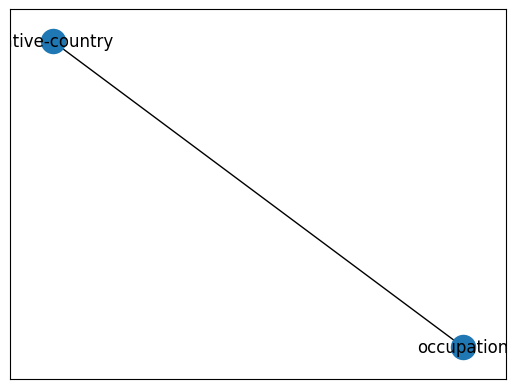

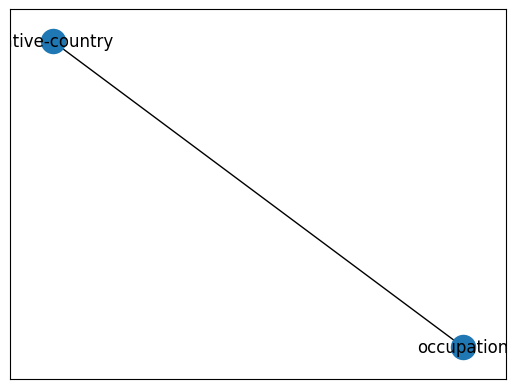

New results added: [('occupation', 'native-country'), ('education', 'occupation', 'native-country')]

Processing of education-num:

Processing of marital-status:
marital-status, relationship, age: score = 0.172994414165715


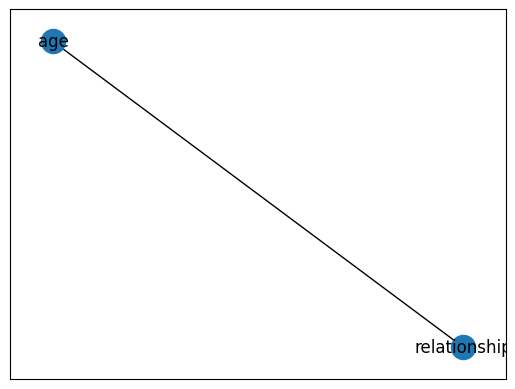

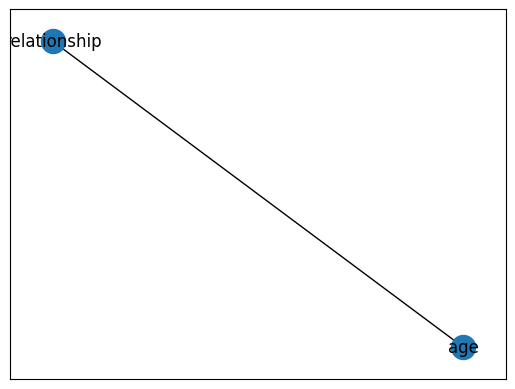

New results added: [('relationship', 'age'), ('marital-status', 'relationship', 'age')]

Processing of occupation:
occupation, workclass, education: score = 0.1120609404630743
occupation, workclass, sex: score = 0.07194545665942569
occupation, workclass, hours-per-week: score = 0.09567296416359246
occupation, education, sex: score = 0.08702558565599833
occupation, education, hours-per-week: score = 0.12281204442845206
occupation, sex, hours-per-week: score = 0.09483591078013068


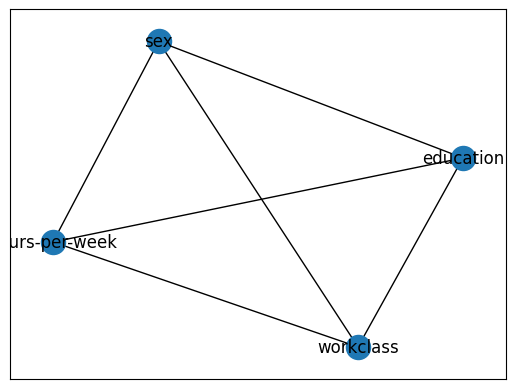

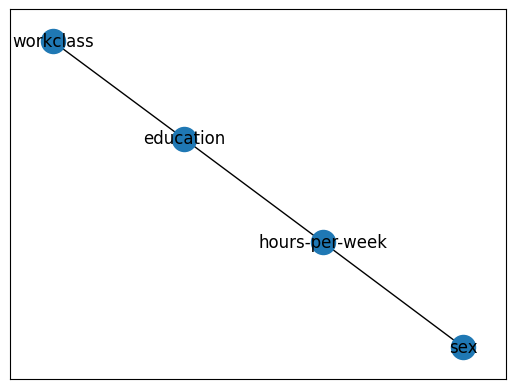

New results added: [('workclass', 'education'), ('education', 'hours-per-week'), ('sex', 'hours-per-week'), ('occupation', 'workclass', 'education'), ('occupation', 'education', 'hours-per-week'), ('occupation', 'sex', 'hours-per-week')]

Processing of relationship:
relationship, marital-status, sex: score = 0.05413632038577143
relationship, marital-status, income: score = 0.021256627037780848
relationship, sex, income: score = 0.020927156661480997


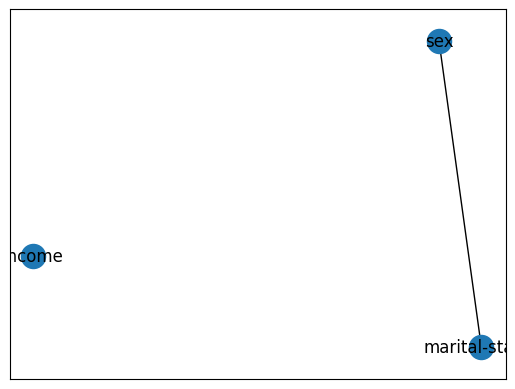

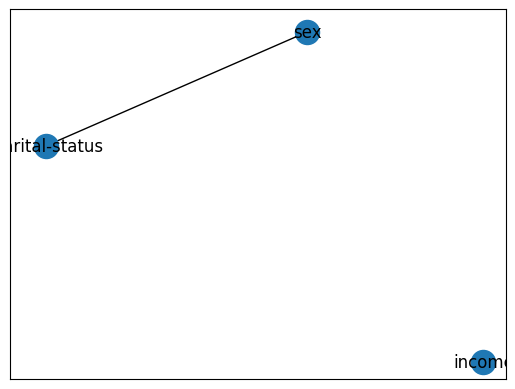

New results added: [('marital-status', 'sex'), ('relationship', 'marital-status', 'sex')]

Processing of race:

Processing of sex:
sex, relationship, occupation: score = 0.18643975084998848


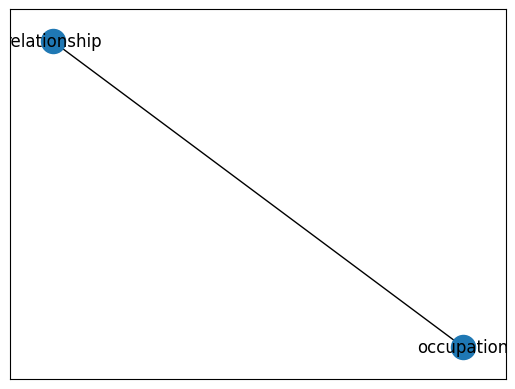

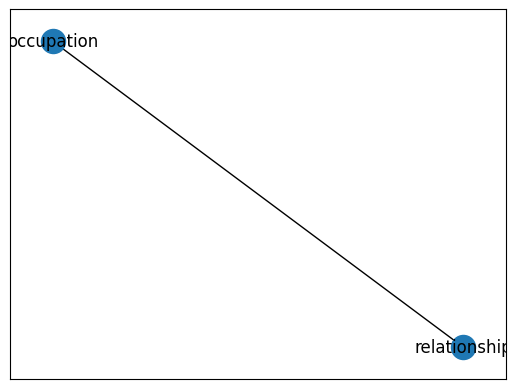

New results added: [('relationship', 'occupation'), ('sex', 'relationship', 'occupation')]

Processing of capital-gain:

Processing of capital-loss:

Processing of hours-per-week:

Processing of native-country:
native-country, race, education: score = 0.06080434212644492
native-country, race, fnlwgt: score = 0.07101376040679355
native-country, education, fnlwgt: score = 0.07386734374341328


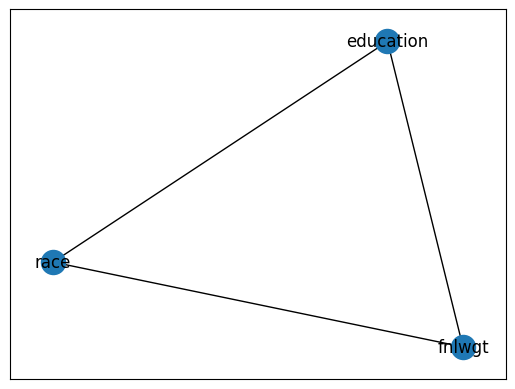

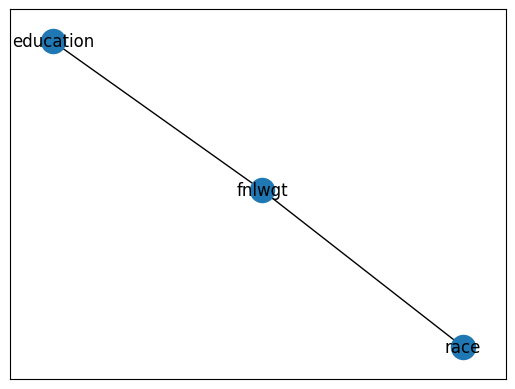

New results added: [('race', 'fnlwgt'), ('education', 'fnlwgt'), ('native-country', 'race', 'fnlwgt'), ('native-country', 'education', 'fnlwgt')]

Processing of income:
income, relationship, capital-gain: score = 0.020739250972706375
income, relationship, capital-loss: score = 0.01925898841084917
income, capital-gain, capital-loss: score = 0.01825999757377661



In [12]:
MINIMUM_SCORE = 0.05
result = []

for attribute in mst.nodes:
    lookup = mutinf_triplets_df.loc[mutinf_triplets_df.A == attribute]
    graph = nx.Graph()
    graph.add_nodes_from(mst.neighbors(attribute))
    
    print(f'Processing of {attribute}:')

    for e1, e2, w in zip(lookup['B'], lookup['C'], lookup['score']):
        print(f'{attribute}, {e1}, {e2}: score = {w}')
        if w >= MINIMUM_SCORE:
            graph.add_edge(e1, e2, weight=w)

    if graph.edges:
        nx.draw_networkx(graph)
        plt.show()
        
        tree = nx.maximum_spanning_tree(graph)
        
        nx.draw_networkx(tree)
        plt.show()
        
        new_result = list(tree.edges)
        new_result += [(attribute,) + e for e in tree.edges]
        print(f'New results added: {new_result}')
        result += new_result
    print()

In [13]:
result

[('occupation', 'native-country'),
 ('education', 'occupation', 'native-country'),
 ('relationship', 'age'),
 ('marital-status', 'relationship', 'age'),
 ('workclass', 'education'),
 ('education', 'hours-per-week'),
 ('sex', 'hours-per-week'),
 ('occupation', 'workclass', 'education'),
 ('occupation', 'education', 'hours-per-week'),
 ('occupation', 'sex', 'hours-per-week'),
 ('marital-status', 'sex'),
 ('relationship', 'marital-status', 'sex'),
 ('relationship', 'occupation'),
 ('sex', 'relationship', 'occupation'),
 ('race', 'fnlwgt'),
 ('education', 'fnlwgt'),
 ('native-country', 'race', 'fnlwgt'),
 ('native-country', 'education', 'fnlwgt')]